# Extracting data and plotting

These data contain temperature on the heating block of a glock 17

Sequence details

- sequence 2: 5 sequential discharges and long cool down
- sequence 3: 5 sequential discharges and long cool down

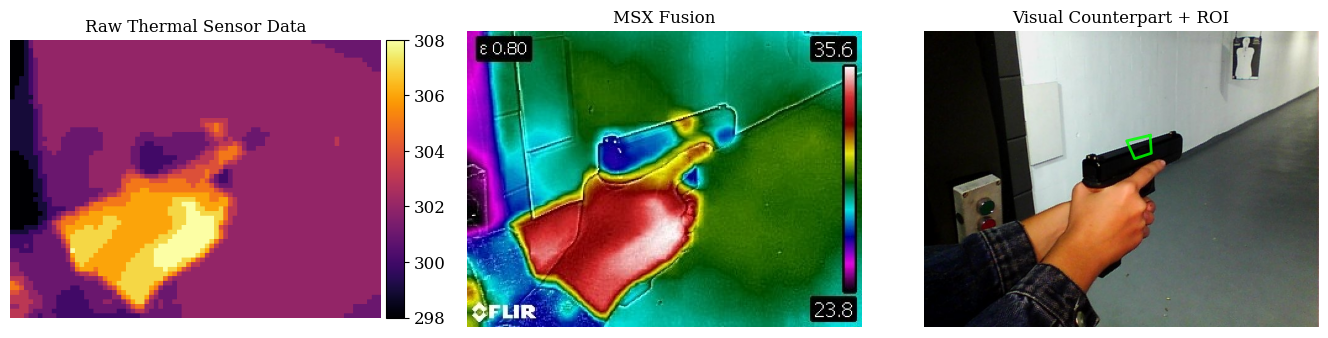

### Defining functions

In [1]:
%pip install scipy numpy pandas matplotlib scikit-learn statsmodels torch sbi nvidia-ml-py

Note: you may need to restart the kernel to use updated packages.


In [2]:
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json

In [3]:
def fit_plot_and_calc_frequency(seq_dir, show_outliers=False, metric='max_temperature_kelvin', min_time=0.0):
    """
    Filters thermal data, calculates mean collection frequency, 
    fits Newton's Law of Cooling and plots the results.
    """
    seq_dir = os.path.abspath(seq_dir)
    seq_name = os.path.basename(seq_dir)
    csv_path = os.path.join(seq_dir, f"{seq_name}_timeseries.csv")

    print(f"Loading sequence: {csv_path}...")
    df = pd.read_csv(csv_path)

    # Filter by minimum time
    if min_time > 0:
        original_len = len(df)
        # Cuts out frames captured before heating event informed by the user
        df = df[df['relative_time_sec'] >= min_time].copy()
        print(f"Trimmed {original_len - len(df)} frames prior to t={min_time}s")
        

    # IQR method for outlier removal
    Q1 = df[metric].quantile(0.25)
    Q3 = df[metric].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)].copy()
    df_outliers = df[(df[metric] < lower_bound) | (df[metric] > upper_bound)].copy()

    t_clean = df_clean['relative_time_sec'].values
    temp_clean = df_clean[metric].values

    # Calculating mean frequency of filtered data
    dt_array = np.diff(t_clean) 
    
    if len(dt_array) > 0:
        mean_dt = np.mean(dt_array)
        mean_freq = 1.0 / mean_dt
    else:
        mean_dt = 0
        mean_freq = 0

    # Fit the exponential decay (affine transformation of Newton's Law) ---
    def thermal_decay(t, A, k, C):
        return A * np.exp(-k * t) + C

    guess_C = np.min(temp_clean)                     
    guess_A = np.max(temp_clean) - guess_C           
    guess_k = 0.01                                   
    p0 = [guess_A, guess_k, guess_C]

    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

    try:
        popt, pcov = curve_fit(thermal_decay, t_clean, temp_clean, p0=p0, bounds=bounds)
        A_fit, k_fit, C_fit = popt

        t_smooth = np.linspace(df['relative_time_sec'].min(), df['relative_time_sec'].max(), 500)
        temp_pred_smooth = thermal_decay(t_smooth, *popt)
        
        temp_pred_clean = thermal_decay(t_clean, *popt)
        r_squared = r2_score(temp_clean, temp_pred_clean)

        # Calculating residuals and variance
        residuals = temp_clean - temp_pred_clean
        # ddof=3 accounts for the 3 parameters estimated by the model (A, k, C)
        residual_variance = np.var(residuals, ddof=3)

        # ADF Test
        adf_result = adfuller(residuals, autolag='AIC') 
        adf_statistic = adf_result[0]
        adf_pvalue = adf_result[1]

        # Determine stationarity based on a 5% significance level
        is_stationary = "Yes" if adf_pvalue < 0.05 else "No"

        #  Data collection statistics
        print(f"\n--- Data Collection Statistics ---")
        print(f"Original Frames: {len(df)}")
        print(f"Clean Frames Retained: {len(df_clean)}")
        print(f"Mean Time Step (Δt): {mean_dt:.4f} seconds")
        print(f"Mean Effective Frequency: {mean_freq:.4f} Hz")

        # Fit statistics
        print(f"\n--- Exponential Decay Fit Results ---")
        print(f"Equation: T(t) = {A_fit:.2f} * e^(-{k_fit:.5f} * t) + {C_fit:.2f}")
        print(f"R-squared: {r_squared:.4f}\n")
        print(f"Residual Variance: {residual_variance:.4f}\n")

        # ADF Results
        print(f"\n--- Residual Stationarity (ADF Test) ---")
        print(f"Test Statistic: {adf_statistic:.4f}")
        print(f"P-value: {adf_pvalue:.4e}")
        print(f"Stationary (p < 0.05): {is_stationary}\n")

        # Plotting
        plt.rcParams.update({
            'font.size': 14,
            'font.family': 'serif', # Matches most academic text
            'axes.labelsize': 16,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 12,
        })

        fig, ax = plt.subplots(figsize=(12, 4))

        ax.scatter(t_clean, temp_clean, color='#00429d', alpha=0.5, s=30, 
                   edgecolors='none', label='Clean Data')
        
        if show_outliers and not df_outliers.empty:
            ax.scatter(df_outliers['relative_time_sec'], df_outliers[metric], 
                       color='#737373', marker='x', alpha=0.8, s=20, label='Outliers')

        ax.plot(t_smooth, temp_pred_smooth, color='#93003a', linewidth=2, 
                 label=f'Decay Fit ($R^2={r_squared:.2f}$)')

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Max Temperature (K)")
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(True, linestyle=':', alpha=0.4, color='gray')

        info_text = (f"$\\Delta t_{{mean}}$: {mean_dt:.3f} s\n"
                     f"Effective frequency: {mean_freq:.2f} Hz\n"
                     f"Residual Variance: {residual_variance:.2f}\n"
                     f"Stationarity (ADF): {is_stationary}")
        
        # Moving the text box to the middle-right to avoid clashing with the legend
        ax.text(0.95, 0.6, info_text, transform=ax.transAxes, 
                 verticalalignment='center', horizontalalignment='right',
                 bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='none'))

        ax.legend(loc='upper right', frameon=False)
        
        plt.tight_layout()
        
        # Save high-res vector and raster formats automatically
        plot_filename_pdf = os.path.join(seq_dir, f"{seq_name}_decay_plot.pdf")
        plot_filename_png = os.path.join(seq_dir, f"{seq_name}_decay_plot.png")
        plt.savefig(plot_filename_pdf, format='pdf', bbox_inches='tight')
        plt.savefig(plot_filename_png, dpi=300, bbox_inches='tight')
        
        plt.show()

    except RuntimeError as e:
        print(f"Curve fitting failed to converge: {e}")

def plot_heat_distribution_histogram(seq_dir, target_time=0.0, bins=50):
    """
    Reads a CSV, finds the frame closest to target_time, extracts and parses 
    the heat_distribution_json, and plots it as a histogram.
    """
    seq_dir = os.path.abspath(seq_dir)
    seq_name = os.path.basename(seq_dir)
    csv_path = os.path.join(seq_dir, f"{seq_name}_timeseries.csv")

    print(f"Loading sequence: {csv_path}...")
    df = pd.read_csv(csv_path)

    # Find the row where relative_time_sec is closest to our target_time
    closest_idx = (df['relative_time_sec'] - target_time).abs().idxmin()
    target_row = df.loc[closest_idx]
    actual_time = target_row['relative_time_sec']
    
    print(f"Target time requested: {target_time}s")
    print(f"Extracting distribution from closest frame at t={actual_time:.3f}s")

    # Parsing the JSON Distribution
    try:
        raw_json = target_row['heat_distribution_json']
        # Parse the JSON string into a Python list
        temp_data = json.loads(raw_json)
        
        # Convert to numpy array and flatten (in case the JSON stored a 2D spatial array)
        temp_array = np.array(temp_data).flatten()
        
        # Optional: Remove any NaN or infinite values that might break the histogram
        temp_array = temp_array[np.isfinite(temp_array)]
        
    except (json.JSONDecodeError, KeyError, TypeError) as e:
        print(f"Failed to parse 'heat_distribution_json' at t={actual_time}s: {e}")
        return

    # Plotting
    plt.rcParams.update({
        'font.size': 14,
        'font.family': 'serif', 
        'axes.labelsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plotting histogram
    counts, edges, patches = ax.hist(
        temp_array, 
        bins=bins, 
        color='#00429d', 
        alpha=0.85, 
        edgecolor='white', 
        linewidth=0.5,
        label=f't = {actual_time:.2f}s'
    )

    # Mean and median lines
    mean_temp = np.mean(temp_array)
    median_temp = np.median(temp_array)
    
    ax.axvline(mean_temp, color='#93003a', linestyle='--', linewidth=2, label=f'Mean ({mean_temp:.1f} K)')
    ax.axvline(median_temp, color='#737373', linestyle=':', linewidth=2, label=f'Median ({median_temp:.1f} K)')

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Pixel Count (Frequency)")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')
    ax.grid(axis='x', visible=False)

    ax.legend(loc='upper right', frameon=False)
    
    plt.tight_layout()
    
    # Save high-res vector and raster formats automatically
    # Appending the time to the filename so you can generate multiple without overwriting
    time_str = f"{actual_time:.1f}".replace('.', 'p')
    plot_filename_pdf = os.path.join(seq_dir, f"{seq_name}_hist_t{time_str}.pdf")
    plot_filename_png = os.path.join(seq_dir, f"{seq_name}_hist_t{time_str}.png")
    
    plt.savefig(plot_filename_pdf, format='pdf', bbox_inches='tight')
    plt.savefig(plot_filename_png, dpi=300, bbox_inches='tight')
    
    plt.show()

    print(f"Plots saved as:\n - {plot_filename_pdf}\n - {plot_filename_png}")
    print(f"Distribution Stats: Min={np.min(temp_array):.2f}K, Max={np.max(temp_array):.2f}K, StdDev={np.std(temp_array):.2f}K")

### Loading and plotting time series

In [ ]:
seq_dir = "./data/sequence_2"
fit_plot_and_calc_frequency(seq_dir, show_outliers=False, min_time=20)#, metric='peak_mean_temperature_kelvin')
plot_heat_distribution_histogram(seq_dir, target_time=20.0, bins=50)

In [ ]:
seq_dir = "./data/sequence_3"
fit_plot_and_calc_frequency(seq_dir, show_outliers=False, min_time=20)#, metric='peak_mean_temperature_kelvin')
plot_heat_distribution_histogram(seq_dir, target_time=20.0, bins=50)

### Testing sampling code

In [6]:
from utils import PFNNewtonSampler

In [7]:
def fit_and_plot_timeseries(t_array: np.ndarray, temp_array: np.ndarray, 
                            min_time: float = 0.0, show_outliers: bool = False, 
                            title: str = "Synthetic Thermal Decay Fit"):
    """
    Filters thermal data in memory, calculates frequency, fits Newton's Law 
    and plots, operating purely on NumPy arrays.
    """
    # Packs into an in-memory DataFrame to reuse your analytical logic
    df = pd.DataFrame({
        'time': t_array,
        'temp': temp_array
    })

    # --- Minimum Time Filter ---
    if min_time > 0:
        original_len = len(df)
        df = df[df['time'] >= min_time].copy()
        print(f"Time trim: Removed {original_len - len(df)} frames prior to t={min_time:.2f}s")

    if df.empty:
        print("Error: No data remaining after minimum time trim.")
        return

    # --- 1. Outlier Filter (IQR Method) ---
    Q1 = df['temp'].quantile(0.25)
    Q3 = df['temp'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df['temp'] >= lower_bound) & (df['temp'] <= upper_bound)].copy()
    df_outliers = df[(df['temp'] < lower_bound) | (df['temp'] > upper_bound)].copy()

    t_clean = df_clean['time'].values
    temp_clean = df_clean['temp'].values

    # --- 2. Calculate Mean Collection Frequency ---
    dt_array = np.diff(t_clean) 
    if len(dt_array) > 0:
        mean_dt = np.mean(dt_array)
        mean_freq = 1.0 / mean_dt
    else:
        mean_dt = 0
        mean_freq = 0

    # --- 3. Exponential Fit (Newton's Law) ---
    def thermal_decay(t, A, k, C):
        return A * np.exp(-k * t) + C

    guess_C = np.min(temp_clean)                     
    guess_A = np.max(temp_clean) - guess_C           
    guess_k = 0.01                                   
    p0 = [guess_A, guess_k, guess_C]
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

    try:
        popt, pcov = curve_fit(thermal_decay, t_clean, temp_clean, p0=p0, bounds=bounds)
        A_fit, k_fit, C_fit = popt

        t_smooth = np.linspace(df['time'].min(), df['time'].max(), 500)
        temp_pred_smooth = thermal_decay(t_smooth, *popt)
        
        temp_pred_clean = thermal_decay(t_clean, *popt)
        r_squared = r2_score(temp_clean, temp_pred_clean)

        # Residuals and Variance
        residuals = temp_clean - temp_pred_clean
        residual_variance = np.var(residuals, ddof=3)

        # ADF Stationarity Test
        adf_result = adfuller(residuals, autolag='AIC') 
        adf_statistic = adf_result[0]
        adf_pvalue = adf_result[1]
        is_stationary = "Yes" if adf_pvalue < 0.05 else "No"

        # Data collection statistics
        print(f"\n--- Data Collection Statistics ---")
        print(f"Original Frames: {len(df)}")
        print(f"Clean Frames Retained: {len(df_clean)}")
        print(f"Mean Time Step (Δt): {mean_dt:.4f} seconds")
        print(f"Mean Effective Frequency: {mean_freq:.4f} Hz")

        # Fit statistics
        print(f"\n--- Exponential Decay Fit Results ---")
        print(f"Equation: T(t) = {A_fit:.2f} * e^(-{k_fit:.5f} * t) + {C_fit:.2f}")
        print(f"R-squared: {r_squared:.4f}\n")
        print(f"Residual Variance: {residual_variance:.4f}\n")

        # ADF test
        print(f"\n--- Residual Stationarity (ADF Test) ---")
        print(f"Test Statistic: {adf_statistic:.4f}")
        print(f"P-value: {adf_pvalue:.4e}")
        print(f"Stationary (p < 0.05): {is_stationary}\n")

        plt.rcParams.update({
            'font.size': 14,
            'font.family': 'serif', 
            'axes.labelsize': 16,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 12,
        })

        fig, ax = plt.subplots(figsize=(12, 4))
        
        ax.scatter(t_clean, temp_clean, color='#00429d', alpha=0.5, s=30, 
                   edgecolors='none', label='Observed Data')
        
        if show_outliers and not df_outliers.empty:
            ax.scatter(df_outliers['time'], df_outliers['temp'], 
                       color='#737373', marker='x', alpha=0.8, s=20, label='Outliers')

        ax.plot(t_smooth, temp_pred_smooth, color='#93003a', linewidth=2, 
                 label=f'Fit ($R^2={r_squared:.2f}$)')

        ax.set_title(title, pad=15)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Max Temperature (K)")
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4, color='gray')

        # Statistics text box
        info_text = (f"$\\Delta t_{{mean}}$: {mean_dt:.3f} s\n"
                     f"Effective Freq: {mean_freq:.2f} Hz\n"
                     f"Residual Var: {residual_variance:.2f}\n"
                     f"Stationary (ADF): {is_stationary}")
        
        ax.text(0.95, 0.6, info_text, transform=ax.transAxes, 
                 verticalalignment='center', horizontalalignment='right',
                 bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='none'))

        ax.legend(loc='upper right', frameon=False)
        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Curve fitting failed to converge: {e}")


--- Ground Truth Generated Parameters (Targets) ---
Environment (C): 295.77 K
Thermal Jump (A_1): 19.05 K
Decay (k): 0.0161 s^-1
Discharge Time (t_0): 19.91 s
Noise Variance: 0.57
Time trim: Removed 27 frames prior to t=19.91s

--- Data Collection Statistics ---
Original Frames: 173
Clean Frames Retained: 173
Mean Time Step (Δt): 0.7538 seconds
Mean Effective Frequency: 1.3267 Hz

--- Exponential Decay Fit Results ---
Equation: T(t) = 26.74 * e^(-0.01494 * t) + 294.97
R-squared: 0.9790

Residual Variance: 0.4956


--- Residual Stationarity (ADF Test) ---
Test Statistic: -12.4954
P-value: 2.8835e-23
Stationary (p < 0.05): Yes



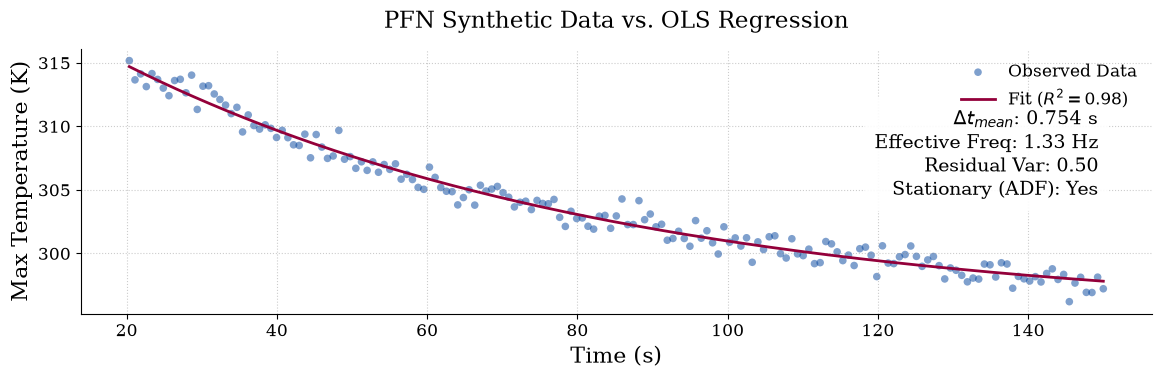

In [8]:
num_timesteps = 200
sampler = PFNNewtonSampler(num_timesteps=num_timesteps, t_min=0.0, t_max=150.0)
t_grid, observed_T, targets = sampler.generate_batch(batch_size=1)

# Extract numpy arrays directly from tensor
t_array = t_grid[0, 0].numpy()
temp_array = observed_T[0, 0].numpy()
ground_truth = targets[0, 0].numpy()

t_0_real = ground_truth[3]

print("\n--- Ground Truth Generated Parameters (Targets) ---")
print(f"Environment (C): {ground_truth[0]:.2f} K")
print(f"Thermal Jump (A_1): {ground_truth[1]:.2f} K")
print(f"Decay (k): {ground_truth[2]:.4f} s^-1")
print(f"Discharge Time (t_0): {t_0_real:.2f} s")
print(f"Noise Variance: {ground_truth[4]:.2f}")

# Pass arrays directly to plotting function
fit_and_plot_timeseries(
    t_array=t_array, 
    temp_array=temp_array, 
    min_time=t_0_real, 
    show_outliers=True,
    title="PFN Synthetic Data vs. OLS Regression"
)


In [ ]:
![ -d "PFNs" ] || git clone https://github.com/SamuelGabriel/PFNs.git
![ -d "npe-pfn" ] || git clone https://github.com/mackelab/npe-pfn.git
%pip install -e ./PFNs ./npe-pfn
# Upgrades tabpfn to make sure fine-tuning tools are avaliable. npe-pfn still works with the newest version
%pip install --upgrade tabpfn

In [ ]:
import os
import requests

# Check if ~/.cache/tabpfn/ exists and create it if it doesn't
cache_dir = os.path.expanduser("~/.cache/tabpfn/")
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Download the checkpoint file if it doesn't already exist
checkpoint_path = os.path.join(cache_dir, "tabpfn-v3-regressor-v3_default.ckpt")
if not os.path.exists(checkpoint_path):
    url = "https://huggingface.co/Prior-Labs/tabpfn_3/resolve/main/tabpfn-v3-regressor-v3_default.ckpt"
    response = requests.get(url)
    with open(checkpoint_path, "wb") as f:
        f.write(response.content)

In [9]:
import torch
from pfns.model import bar_distribution
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors import Batch

In [ ]:
# Funtion to read a sequence CSV and return a tensor more suitable for PFN input
def read_sequence(seq_dir, seq_name, metric='max_temperature_kelvin', min_time=0.0):
    csv_path = os.path.join(seq_dir, f"{seq_name}_timeseries.csv")

    print(f"Loading sequence: {csv_path}...")
    df = pd.read_csv(csv_path)

    # Filter by minimum time
    if min_time > 0:
        original_len = len(df)
        # Cuts out frames captured before heating event informed by the user
        df = df[df['relative_time_sec'] >= min_time].copy()
        print(f"Trimmed {original_len - len(df)} frames prior to t={min_time}s")
        

    # IQR method for outlier removal
    Q1 = df[metric].quantile(0.25)
    Q3 = df[metric].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)].copy()

    # Convert to torch tensors for PFN input
    t_tensor = torch.tensor(df_clean['relative_time_sec'].values, dtype=torch.float32)
    temp_tensor = torch.tensor(df_clean[metric].values, dtype=torch.float32)
    return torch.stack((t_tensor, temp_tensor), dim=1)  # Shape: (N, 2)

In [11]:
seq_2 = read_sequence("./data/sequence_2", "sequence_2", min_time=20.0)
seq_3 = read_sequence("./data/sequence_3", "sequence_3", min_time=20.0)

# Interleave the time and temperature data from both sequences
seq_2 = seq_2.reshape(1, -1)
seq_3 = seq_3.reshape(1, -1)

Loading sequence: ./data/sequence_2/sequence_2_timeseries.csv...
Trimmed 3 frames prior to t=20.0s
Loading sequence: ./data/sequence_3/sequence_3_timeseries.csv...
Trimmed 2 frames prior to t=20.0s


In [ ]:
# Function to generate batches from the sampler for training
def get_batch_from_sampler(
        sampler,
        batch_size=2,               # How many batches to generate
        seq_len=100,                # How many sequences per batch
        num_features=num_timesteps, # How many features per sequence (e.g., number of time steps)
        device='cpu',               # Device to place the tensors on
        all_targets=False,          # If True, returns all targets (ys) in the Batch; if False, returns only the selected target by target_idx
        target_idx=None,            # If all_targets is False, this index selects which target (ys) to return in the Batch
        include_t_grid=True,        # If True, includes the timestamps (t_grid) as interleaved features with the observed temperatures; if False, only the observed temperatures are returned
        min_num_features=None,      # If specified, generates a random number of features for each sample in the batch, ensuring it's at least min_num_features
        **kwargs,
    ):
    t_grid, xs, ys = sampler.generate_batch(batch_size=batch_size, seq_len=seq_len, num_features=num_features)

    if include_t_grid:
        # Interleave t_grid values with the observed temperatures in xs
        stacked = torch.stack([xs, t_grid], dim=-1)  # Stack along a new last dimension
        new_shape = list(xs.shape)
        new_shape[-1] = -1  # Flatten the last two dimensions to interleave
        xs = stacked.reshape(new_shape)  # Reshape to interleave t_grid and xs
    
    if min_num_features is not None:
        min_num_features *= 2 if include_t_grid else 1  # Adjust for interleaving
        if xs.shape[2] < min_num_features:
            raise ValueError(f"Generated number of features {xs.shape[2]} is less than the specified minimum {min_num_features}.")

        # Randomize number of features for each sample in the batch, ensuring it's at least min_num_features
        random_lengths = torch.randint(min_num_features, xs.shape[2] + 1, (batch_size, seq_len))
        
        # Replace values beyond the random length with nan
        for i in range(batch_size):
            for j in range(seq_len):
                length = random_lengths[i, j].item()
                if length < xs.shape[2]:
                    xs[i, j, length:] = float('nan')
                    ys[i, j, length:] = float('nan')
    
    if all_targets:
        return Batch(x=xs.to(device), y=ys.to(device), target_y=ys.to(device))

    # If target_idx is not specified, randomly select one for each sample in the batch
    if target_idx is None:
        target_idx = torch.randint(0, ys.shape[-1], (1,))  # Randomly select a target index for each sample
    xs = torch.cat([xs, ys[:, :, :target_idx]], dim=-1)  # Concatenate the additional features to xs
    return Batch(x=xs.to(device), y=ys[:, :, target_idx].to(device), target_y=ys[:, :, target_idx].to(device))

# Needed for torch serialization to work with custom functions and classes
torch.serialization.add_safe_globals([get_batch_from_sampler, PFNNewtonSampler, torch.distributions.uniform.Uniform])

num_features = num_timesteps
num_targets = 5
max_dataset_size = 20

def train_a_pfn(
        sampler,
        epochs=10,
        num_features=num_features,
        num_targets=num_targets,
        include_t_grid=True,
        max_dataset_size=max_dataset_size,
        batch_size=256,
        steps_per_epoch=100,
        state_dict_path=None,
    ):

    # define a bar distribution (riemann distribution) criterion with 1000 bars
    ys_list = []
    for target_idx in range(num_targets):
        ys = get_batch_from_sampler(
            sampler,
            # batch_size=100000,
            batch_size=500,
            seq_len=20,
            num_features=num_features,
            target_idx=target_idx,
        ).target_y
        ys_list.append(ys)
    # we define our bar distribution adaptively with respect to the above sample of target ys from our prior
    borders = bar_distribution.get_bucket_borders(
        # num_outputs=1000,
        num_outputs=250,
        ys=torch.cat(ys_list),
    ).tolist()

    if include_t_grid:
        features_per_group = num_features * 2 + num_targets -1 # Double the number of features to account for t_grid interleaving
    else:
        features_per_group = num_features + num_targets - 1

    # Config adapted from https://github.com/SamuelGabriel/PFNs
    config = MainConfig(
        priors=[AdhocPriorConfig(get_batch_methods=[get_batch_from_sampler], prior_kwargs={'sampler': sampler, 'include_t_grid': include_t_grid})],
        optimizer=OptimizerConfig('adamw', lr=.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            # emsize=512, nhead=8, nhid=1024, nlayers=6,
            emsize=64, nhead=4, nhid=64, nlayers=2,
            features_per_group=features_per_group, attention_between_features=False,
            # The encoder config ensures the uniform inputs between 0 and 1 have mean 0 and var 1
            encoder=EncoderConfig(train_normalization=True),
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=batch_size,
            min_single_eval_pos=2,
            max_seq_len=max_dataset_size,
            min_num_features=num_features,
            max_num_features=num_features,
        ),
        epochs=epochs, warmup_epochs=epochs//4, steps_per_epoch=steps_per_epoch,
        num_workers=0,
        train_state_dict_save_path=state_dict_path,
        train_state_dict_load_path=state_dict_path,
    )
    train_result = train(config, device='cuda', reusable_config=False)
    return train_result

In [ ]:
train_result = train_a_pfn(
    sampler,
    epochs=1,
    include_t_grid=True,
    state_dict_path=os.path.join(os.getcwd(), 'pfn_transformer_state_dict.pt'), # Checkpoints path
)

In [ ]:
from custom_npe_pfn import Custom_NPE_PFN

# Generate data to test the model
_, x_o, _ = sampler.generate_batch(batch_size=1, seq_len=1)

# Generate data to fit the model
num_simulations = 1000
t_grid, xs, thetas = sampler.generate_batch(batch_size=1, seq_len=num_simulations)

posterior_estimator = Custom_NPE_PFN(
    model=train_result['model'], # Uses the trained model from the previous step
    show_progress_bars=True,
    prior=sampler.prior,
)
posterior_estimator.append_simulations(thetas.squeeze(0), xs.squeeze(0))

# NO TRAINING!

num_posterior_samples = 2 # 10000
posterior_samples = posterior_estimator.sample((num_posterior_samples,), x=x_o.squeeze(0))

Drawing 2 posterior samples: 107it [00:10, 10.58it/s]


In [ ]:
from npe_pfn import TabPFN_Based_NPE_PFN

num_simulations = 1000
# Real data sequences have different lengths, so we generate training data of varying lengths to ensure the PFN can handle this variability
# We will pad the sequences with NaN values to ensure uniform length for the PFN.
min_features = 30
max_features = 50
batch = get_batch_from_sampler(
    sampler,
    batch_size=1,
    seq_len=num_simulations,
    num_features=max_features,
    all_targets=True,
    min_num_features=min_features,
)

num_features_with_timestamps = max_features * 2  # Each feature has a corresponding timestamp

# Pad sequences with nan to ensure uniform length for the PFN
padded_seq_2 = torch.cat([seq_2, torch.full((1, num_features_with_timestamps - seq_2.shape[1]), float('nan'))], dim=1)
padded_seq_3 = torch.cat([seq_3, torch.full((1, num_features_with_timestamps - seq_3.shape[1]), float('nan'))], dim=1)

init_kwargs = {
    'prior': sampler.prior,
    'show_progress_bars': True,
    'regressor_init_kwargs': {
        # 'model_path': 'tabpfn-v3-regressor-v3_default.ckpt',
        'device': 'cuda',
    },
}

posterior_estimator = TabPFN_Based_NPE_PFN(**init_kwargs)
posterior_estimator.append_simulations(batch.y.squeeze(0), batch.x.squeeze(0))

# NO TRAINING!
num_posterior_samples = 10000
posterior_samples_seq_2 = posterior_estimator.sample((num_posterior_samples,), x=padded_seq_2)
posterior_samples_seq_3 = posterior_estimator.sample((num_posterior_samples,), x=padded_seq_3)

del posterior_estimator

Drawing 10000 posterior samples: 10493it [01:29, 117.75it/s]                          
Drawing 10000 posterior samples: 10012it [01:14, 134.43it/s]                          


In [ ]:
from tabpfn.finetuning import FinetunedTabPFNRegressor

training_x = []
training_y = []
# Change this value based on GPU memory capacity
training_seq_len = 600

# Generate training data for each target index and pad sequences with NaN to ensure uniform length
for target_idx in range(num_targets):
    batch_target = get_batch_from_sampler(
        sampler,
        batch_size=1,
        seq_len=training_seq_len,
        num_features=num_features,
        target_idx=target_idx,
        min_num_features=min_features,
    )
    padded_x = torch.cat([batch_target.x.squeeze(0), torch.full((training_seq_len, num_targets - target_idx - 1), float('nan'))], dim=1)
    training_x.append(padded_x)
    training_y.append(batch_target.y.squeeze(0))

training_x = torch.cat(training_x)
training_y = torch.cat(training_y)

# Fine-tune the TabPFN model on the generated training data
finetuned_model = FinetunedTabPFNRegressor(device='cuda')
finetuned_model.fit(training_x, training_y)

In [ ]:
ft_posterior_estimator = TabPFN_Based_NPE_PFN(**init_kwargs)

# Replaces the internal model of the posterior estimator with the fine-tuned model for inference
ft_posterior_estimator._model = finetuned_model.finetuned_inference_regressor_
ft_posterior_estimator.append_simulations(batch.y.squeeze(0), batch.x.squeeze(0))

ft_posterior_samples_seq_2 = ft_posterior_estimator.sample((num_posterior_samples,), x=padded_seq_2)
ft_posterior_samples_seq_3 = ft_posterior_estimator.sample((num_posterior_samples,), x=padded_seq_3)

del ft_posterior_estimator

Drawing 10000 posterior samples: 10871it [01:06, 162.34it/s]                          
Drawing 10000 posterior samples: 10538it [01:03, 164.98it/s]                          


In [ ]:
# Save data to csv files for later analysis
def save_posterior_samples_to_csv(
        filename,
        posterior_samples_seq_2,
        posterior_samples_seq_3,
        ft_posterior_samples_seq_2,
        ft_posterior_samples_seq_3,
    ):
    """
    Saves posterior samples to a CSV file.
    """
    # Create a DataFrame to hold all samples
    df = pd.DataFrame({
        'posterior_samples_seq_2': posterior_samples_seq_2.numpy().flatten(),
        'posterior_samples_seq_3': posterior_samples_seq_3.numpy().flatten(),
        'ft_posterior_samples_seq_2': ft_posterior_samples_seq_2.numpy().flatten(),
        'ft_posterior_samples_seq_3': ft_posterior_samples_seq_3.numpy().flatten(),
    })

    # Save to CSV
    df.to_csv(filename, index=False)
    print(f"Posterior samples saved to {filename}")
    

save_posterior_samples_to_csv(
    "posterior_samples.csv",
    posterior_samples_seq_2,
    posterior_samples_seq_3,
    ft_posterior_samples_seq_2,
    ft_posterior_samples_seq_3,
)